# Customer Churn Prediction: IBM Telco dataset

**Business problem.** We are data scientists at a telecom company. The retention team wants a ranked list of customers who are likely to leave, so they can be contacted *before* they churn. This notebook builds and evaluates a **Decision Tree** classifier for that purpose, saves the full preprocessing + model pipeline, and hands it to a Flask REST API (`app.py`).

**Workflow:** Business problem → Data → Preparation → EDA → Feature engineering → Model → Evaluation → Interpretation → Saved model → API

| Section | Content |
|---|---|
| 1 | Data understanding and preparation (checks, cleaning decisions, 70:30 split) |
| 2 | Exploratory data analysis (8 visualisations with business insights) |
| 3 | Feature engineering (4 new features) |
| 4 | Model development (6 configurations, hyper-parameter tuning, Random Forest comparison) |
| 5 | Model evaluation (accuracy, precision, recall, F1, confusion matrix, business reading) |
| 6 | Model interpretation (feature importance, tree visualisation) |
| 7 | Saving the model and reusing it on new customers |

**Two rules followed throughout:** (1) the data is split *before* anything is fitted or explored, and the test set is used only once, at the end; (2) all cleaning and feature engineering lives in `src/features.py` inside one sklearn `Pipeline`, so training and the API run *identical* code.

In [1]:
import sys, json, warnings, textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sklearn

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)

warnings.filterwarnings("ignore")

# The notebook lives in notebook/ and the shared code in src/. Make `src` importable
# whether the notebook is started from notebook/ or from the project root.
ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.features import (CleanAndEngineer, build_pipeline, RAW_FEATURE_COLUMNS,
                          RAW_NUMERIC, RAW_CATEGORICAL, ADDON_COLS)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

print("Project folder:", ROOT.name)
print(f"pandas {pd.__version__} | numpy {np.__version__} | scikit-learn {sklearn.__version__}")

Project folder: customer_churn_project
pandas 3.0.2 | numpy 2.4.4 | scikit-learn 1.8.0


## 1. Data understanding and preparation
### 1.1 Load and first look

In [2]:
df_raw = pd.read_csv(ROOT / "data" / "TelcoCustomerChurn.csv")
print(f"Rows: {df_raw.shape[0]:,} | Columns: {df_raw.shape[1]}")
df_raw.head()

Rows: 7,043 | Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# The data dictionary supplied with the dataset
data_dict = pd.read_csv(ROOT / "data" / "TelcoCustomerChurn_-_Data_Dictionary.csv")
data_dict

,Column,Data Type,Description,Example / Values
0,customerID,Categorical / ID,Unique identifier for each customer,7590-VHVEG
1,gender,Categorical,Gender of the customer,"Male, Female"
2,SeniorCitizen,Numerical / Binary,Indicates whether the customer is a senior cit...,"0, 1"
3,Partner,Categorical,Whether the customer has a partner,"Yes, No"
4,Dependents,Categorical,Whether the customer has dependents,"Yes, No"
5,tenure,Numerical,Number of months the customer has been with th...,"1, 24, 72"
6,PhoneService,Categorical,Whether the customer has phone service,"Yes, No"
7,MultipleLines,Categorical,Whether the customer has multiple phone lines,"Yes, No, No phone service"
8,InternetService,Categorical,Type of internet service subscribed to,"DSL, Fiber optic, No"
9,OnlineSecurity,Categorical,Whether the customer has online security service,"Yes, No, No internet service"


### 1.2 Data types and structure

In [4]:
structure = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "n_unique": df_raw.nunique(),
    "example": df_raw.iloc[0],
})
structure

,dtype,n_unique,example
customerID,str,7043,7590-VHVEG
gender,str,2,Female
SeniorCitizen,int64,2,0
Partner,str,2,Yes
Dependents,str,2,No
tenure,int64,73,1
PhoneService,str,2,No
MultipleLines,str,3,No phone service
InternetService,str,3,DSL
OnlineSecurity,str,3,No


**Observation.** `TotalCharges` is stored as *text* even though it is a monetary amount; something in the column stops pandas parsing it as a number. `SeniorCitizen` is already 0/1. `customerID` is unique per row (7,043 distinct values), so it is an identifier and carries no predictive signal.

### 1.3 Missing-value analysis
Missing data is not always `NaN`, so blank or whitespace-only strings are checked as well.

In [5]:
nulls = df_raw.isna().sum()
print("Columns containing NaN:", nulls[nulls > 0].to_dict() or "none")

blank = df_raw.astype(str).apply(lambda s: s.str.strip().eq("").sum())
print("Blank-string cells per column:", blank[blank > 0].to_dict())

Columns containing NaN: none
Blank-string cells per column: {'TotalCharges': 11}


In [6]:
blank_tc = df_raw[df_raw["TotalCharges"].str.strip() == ""]
display(blank_tc[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]])
print("tenure values in these rows:", blank_tc["tenure"].unique().tolist())
print("Churn values in these rows :", blank_tc["Churn"].unique().tolist())

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


tenure values in these rows: [0]
Churn values in these rows : ['No']


**Observation and decision.** There are no `NaN` values, but `TotalCharges` contains **11 blank strings**. All 11 customers have `tenure = 0` and none has churned: they have just joined and have not received a first bill. The blank therefore means "nothing billed yet", i.e. **0**, not "unknown".

**Decision: impute `0`** rather than the median. A median (~1,400) would tell the model these brand-new customers already spent a lot. The fill value is a constant, not a statistic learned from the data, so it cannot leak information between train and test. The step lives inside the pipeline (`CleanAndEngineer`), so the API treats a blank `TotalCharges` the same way.

### 1.4 Duplicate analysis

In [7]:
print("Fully duplicated rows                 :", df_raw.duplicated().sum())
print("Duplicated customerID                 :", df_raw["customerID"].duplicated().sum())

no_id = df_raw.drop(columns="customerID")
print("Extra rows with an identical profile  :", no_id.duplicated().sum(), "(ignoring customerID)")

profile_dups = no_id.duplicated(keep=False)
groups = df_raw[profile_dups].groupby(RAW_FEATURE_COLUMNS)["Churn"].nunique()
print(f"Duplicate-profile groups: {len(groups)} | groups whose members disagree on Churn: {(groups > 1).sum()}")
df_raw[profile_dups].sort_values(RAW_FEATURE_COLUMNS).head(6)

Fully duplicated rows                 : 0
Duplicated customerID                 : 0
Extra rows with an identical profile  : 22 (ignoring customerID)
Duplicate-profile groups: 20 | groups whose members disagree on Churn: 0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6491,9728-FTTVZ,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.20,69.2,Yes
6764,7660-HDPJV,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.20,69.2,Yes
4495,4702-IOQDC,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.10,70.1,Yes
6267,0328-GRPMV,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.10,70.1,Yes
5522,2619-WFQWU,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.15,70.15,Yes
5759,9985-MWVIX,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.15,70.15,Yes


**Observation and decision.** No row is duplicated and no ID repeats. Ignoring `customerID`, 22 rows share a profile with another customer. With ~19 mostly low-cardinality columns, identical profiles are expected by chance among 7,043 people, and each row has a different `customerID`, i.e. a different real customer.

**Decision: keep them.** Dropping real customers would shrink the data and slightly bias it toward unusual profiles. As a check, the members of every duplicate-profile group carry the *same* churn label (0 conflicting groups above), so they are not label noise.

### 1.5 Numerical and categorical features

In [8]:
print("Numerical  :", RAW_NUMERIC, " (SeniorCitizen is a 0/1 flag)")
print("Categorical:", RAW_CATEGORICAL)
print("Dropped    : ['customerID'] (identifier), 'Churn' (target)")
print()

levels = pd.DataFrame({c: [" | ".join(sorted(df_raw[c].unique()))] for c in RAW_CATEGORICAL}, index=["levels"]).T
levels

Numerical  : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']  (SeniorCitizen is a 0/1 flag)
Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Dropped    : ['customerID'] (identifier), 'Churn' (target)



,levels
gender,Female | Male
Partner,No | Yes
Dependents,No | Yes
PhoneService,No | Yes
MultipleLines,No | No phone service | Yes
InternetService,DSL | Fiber optic | No
OnlineSecurity,No | No internet service | Yes
OnlineBackup,No | No internet service | Yes
DeviceProtection,No | No internet service | Yes
TechSupport,No | No internet service | Yes


In [9]:
tc_num = pd.to_numeric(df_raw["TotalCharges"], errors="coerce")
display(df_raw.assign(TotalCharges=tc_num)[["tenure", "MonthlyCharges", "TotalCharges"]].describe().round(2))

# Consistency checks that justify the encoding and the API validation rules
phone_ok = ((df_raw["MultipleLines"] == "No phone service") == (df_raw["PhoneService"] == "No")).all()
net_ok = all(((df_raw[c] == "No internet service") == (df_raw["InternetService"] == "No")).all() for c in ADDON_COLS)
print("'No phone service' appears exactly when PhoneService = No     :", phone_ok)
print("'No internet service' appears exactly when InternetService = No:", net_ok)

ratio = (tc_num / (df_raw["tenure"] * df_raw["MonthlyCharges"])).replace(np.inf, np.nan)
print("TotalCharges / (tenure x MonthlyCharges), 5th/50th/95th percentile:",
      ratio.quantile([0.05, 0.5, 0.95]).round(2).tolist())

,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7032.00
mean,32.37,64.76,2283.30
std,24.56,30.09,2266.77
min,0.00,18.25,18.80
25%,9.00,35.50,401.45
50%,29.00,70.35,1397.48
75%,55.00,89.85,3794.74
max,72.00,118.75,8684.80


'No phone service' appears exactly when PhoneService = No     : True
'No internet service' appears exactly when InternetService = No: True
TotalCharges / (tenure x MonthlyCharges), 5th/50th/95th percentile: [0.92, 1.0, 1.07]


**Observations.**
- Tenure runs 0-72 months; `MonthlyCharges` roughly 18-119. No impossible values.
- `TotalCharges` is close to `tenure × MonthlyCharges` (median ratio 1.0), so it is largely a function of the other two. This is harmless for a tree but explains why they will correlate strongly.
- "No phone service" and "No internet service" are fully determined by `PhoneService` and `InternetService`. They are redundant but harmless, and are kept as valid categories. The API uses these facts as consistency checks on incoming requests.

### 1.6 Target-variable analysis

In [10]:
counts = df_raw["Churn"].value_counts()
target_summary = pd.DataFrame({"customers": counts, "share_%": (counts / len(df_raw) * 100).round(2)})
display(target_summary)
print(f"A 'model' that predicts 'No' for everybody would already be {counts['No'] / len(df_raw):.1%} accurate,")
print("so accuracy alone is a poor yardstick here; precision, recall and F1 on the churn class matter more.")

,customers,share_%
Churn,,
No,5174,73.46
Yes,1869,26.54


A 'model' that predicts 'No' for everybody would already be 73.5% accurate,
so accuracy alone is a poor yardstick here; precision, recall and F1 on the churn class matter more.


**Observation.** The classes are imbalanced: roughly 1 customer in 4 churns (26.5%). Consequences: (1) the train/test split must be **stratified**, (2) accuracy is misleading, and (3) class weighting is worth testing during modelling.

### 1.7 Train/test split (70:30, `random_state = 42`)
The split happens **now, before any exploration or fitting**, so nothing about the test set can influence a decision. Splitting is stratified so both parts keep the same churn rate.

In [11]:
X = df_raw.drop(columns=["customerID", "Churn"])
y = df_raw["Churn"].map({"No": 0, "Yes": 1})
assert y.notna().all()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

pd.DataFrame({
    "rows": [len(X_train), len(X_test)],
    "share_%": [round(len(X_train) / len(X) * 100, 1), round(len(X_test) / len(X) * 100, 1)],
    "churn_rate_%": [round(y_train.mean() * 100, 2), round(y_test.mean() * 100, 2)],
}, index=["train", "test"])

,rows,share_%,churn_rate_%
train,4930,70.0,26.53
test,2113,30.0,26.55


### 1.8 Key preprocessing decisions

| Decision | Why |
|---|---|
| Drop `customerID` | Unique identifier, no signal; keeping it would let a tree memorise individual customers. |
| Encode target `Yes/No` → `1/0` | Churn is the positive class, so precision/recall refer to churners. |
| `TotalCharges`: coerce to number, blanks → 0 | New customers (tenure 0) have not been billed. Constant fill = no leakage. |
| One-hot encode categoricals | Trees in scikit-learn need numeric input; one-hot avoids inventing an order for unordered categories. |
| No scaling | Decision trees split on thresholds and are insensitive to feature scale. |
| `OneHotEncoder(handle_unknown="ignore")` | An unseen category in the API becomes an all-zero row instead of an error. |
| Cleaning + encoding + model in **one `Pipeline`** | Everything fitted sees only training data (cross-validation refits it per fold), and the same object is saved and served. |

**Leakage checklist:** split first ✔ · EDA on the training set only ✔ · only stateless steps before the split ✔ · encoder and model fitted on training data only ✔ · model chosen with cross-validation on the training set ✔ · test set touched once, in section 5 ✔

## 2. Exploratory data analysis
EDA uses the **training set only** (`X_train` with its labels), so the test set stays untouched. Each chart is followed by a business insight.

In [12]:
# Cleaned copy of the training data for EDA (stateless cleaning: TotalCharges -> number)
clean_train = CleanAndEngineer(add_features=False).fit_transform(X_train)
eda = clean_train.assign(Churn=y_train)
eda["ChurnLabel"] = eda["Churn"].map({0: "No", 1: "Yes"})
overall_rate = eda["Churn"].mean()

PALETTE = {"No": "#4C78A8", "Yes": "#E45756"}

def rate_bar(ax, col, data=None, order=None, title=None):
    """Bar chart of churn rate (%) per category, annotated with group size."""
    data = eda if data is None else data
    t = data.groupby(col)["Churn"].agg(rate="mean", n="size")
    t = t.loc[order] if order is not None else t.sort_values("rate", ascending=False)
    labels = [textwrap.fill(str(i), 13) for i in t.index]
    bars = ax.bar(labels, t["rate"] * 100, color="#4C78A8")
    for b, (r, n) in zip(bars, zip(t["rate"], t["n"])):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1, f"{r*100:.1f}%\nn={n:,}",
                ha="center", va="bottom", fontsize=9)
    ax.axhline(overall_rate * 100, ls="--", lw=1, color="grey")
    ax.set_ylabel("Churn rate (%)"); ax.set_xlabel("")
    ax.set_ylim(0, t["rate"].max() * 100 * 1.3)
    if title: ax.set_title(title)
    return t

print(f"Training set: {len(eda):,} customers | overall churn rate {overall_rate:.1%}")

Training set: 4,930 customers | overall churn rate 26.5%


### 2.1 Churn distribution

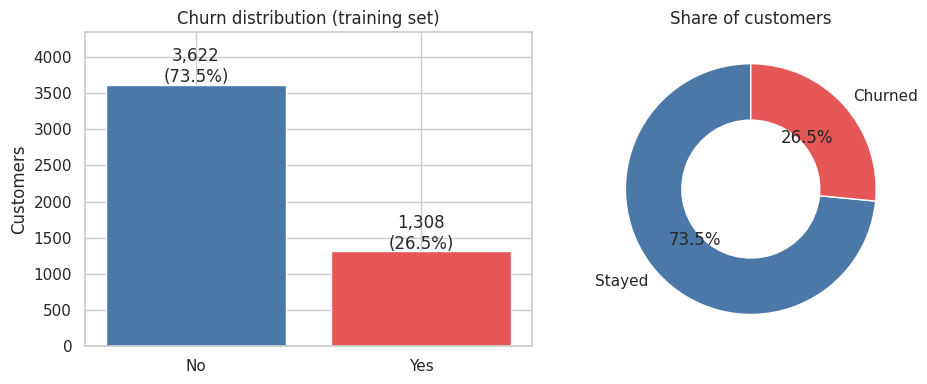

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
counts = eda["ChurnLabel"].value_counts().reindex(["No", "Yes"])
ax[0].bar(counts.index, counts.values, color=[PALETTE["No"], PALETTE["Yes"]])
for i, v in enumerate(counts.values):
    ax[0].text(i, v + 40, f"{v:,}\n({v/len(eda):.1%})", ha="center")
ax[0].set_title("Churn distribution (training set)"); ax[0].set_ylabel("Customers")
ax[0].set_ylim(0, counts.max() * 1.2)
ax[1].pie(counts.values, labels=["Stayed", "Churned"], colors=[PALETTE["No"], PALETTE["Yes"]],
          autopct="%1.1f%%", startangle=90, wedgeprops=dict(width=0.45))
ax[1].set_title("Share of customers")
plt.tight_layout(); plt.show()

**Business insight.** About one customer in four leaves. That is a large, expensive leak, and also an *imbalanced* problem: a model can look accurate (~73%) by ignoring churners altogether. We must judge the model on how many churners it finds (recall) and how clean its alerts are (precision), not on accuracy.

### 2.2 Churn by contract type (customer/service characteristic)

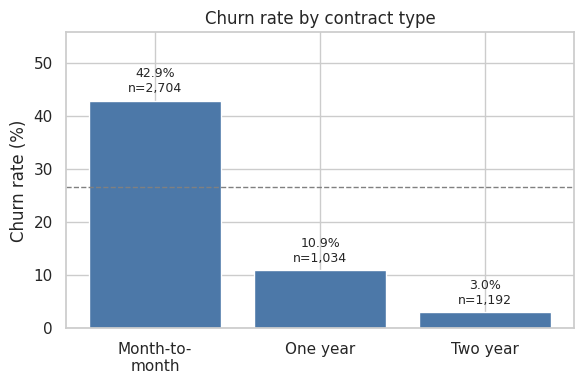

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
t = rate_bar(ax, "Contract", order=["Month-to-month", "One year", "Two year"], title="Churn rate by contract type")
plt.tight_layout(); plt.show()

**Business insight.** Contract type is the strongest single separator in the data. Month-to-month customers churn at roughly 43%, about four times the rate of one-year customers (~11%) and about 14 times the rate of two-year customers (~3%). Month-to-month customers owe nothing on leaving, so they are the natural target for retention offers, especially offers that move them onto a longer contract.

### 2.3 Tenure: distribution and churn rate (numerical variable)

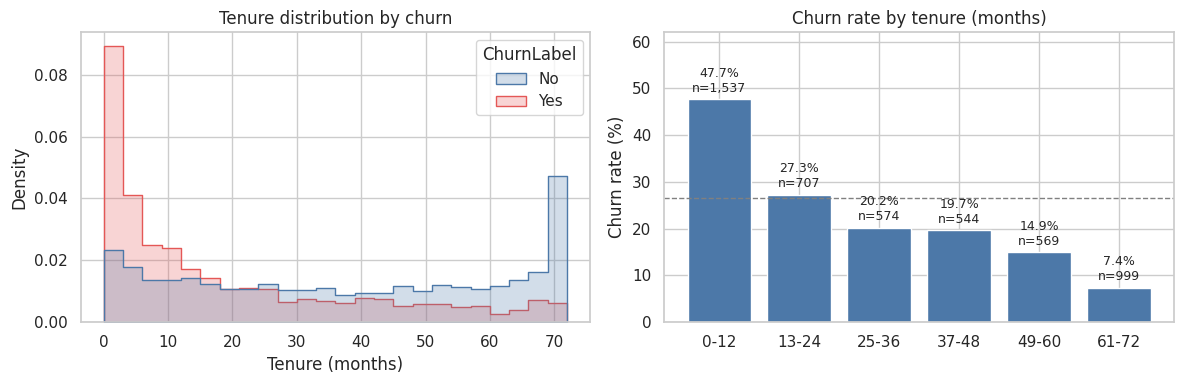

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=eda, x="tenure", hue="ChurnLabel", bins=24, stat="density", common_norm=False,
             palette=PALETTE, element="step", ax=ax[0])
ax[0].set_title("Tenure distribution by churn"); ax[0].set_xlabel("Tenure (months)")

buckets = ["0-12", "13-24", "25-36", "37-48", "49-60", "61-72"]
tmp = eda.assign(tenure_bucket=pd.cut(eda["tenure"], [-1, 12, 24, 36, 48, 60, 72], labels=buckets).astype(str))
rate_bar(ax[1], "tenure_bucket", data=tmp, order=buckets, title="Churn rate by tenure (months)")
plt.tight_layout(); plt.show()

**Business insight.** Churn is concentrated in the first year: nearly half of customers with under 12 months of tenure leave, and the rate falls steadily with every additional year. Churners are heavily piled up at the left of the distribution, whereas loyal customers show a second cluster at 70+ months. The first 12 months are the critical window: onboarding quality and early-life offers matter most.

### 2.4 Monthly and total charges by churn (numerical relationship)

,tenure,MonthlyCharges,TotalCharges
ChurnLabel,,,
No,38.0,64.4,1673.6
Yes,10.0,80.0,705.1


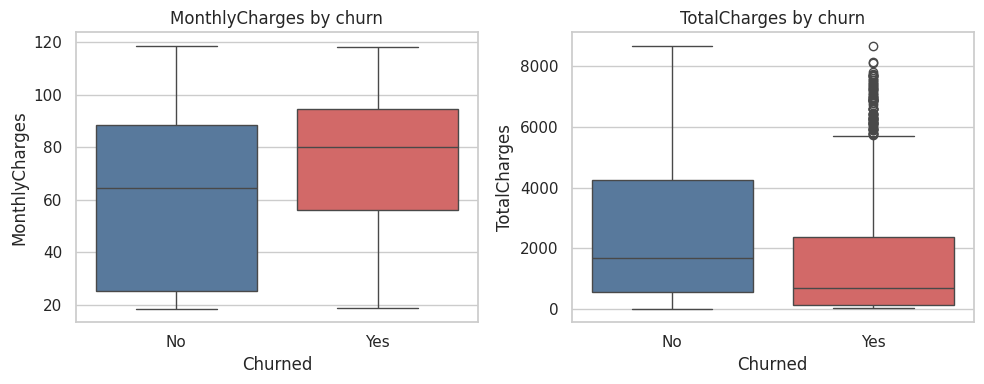

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for a, col in zip(ax, ["MonthlyCharges", "TotalCharges"]):
    sns.boxplot(data=eda, x="ChurnLabel", y=col, order=["No", "Yes"], hue="ChurnLabel",
                palette=PALETTE, legend=False, ax=a)
    a.set_title(f"{col} by churn"); a.set_xlabel("Churned")
plt.tight_layout(); plt.show()

eda.groupby("ChurnLabel")[["tenure", "MonthlyCharges", "TotalCharges"]].median().round(1)

**Business insight.** Churners pay *more* per month (higher median monthly bill) yet have a much *lower* total spend, because they leave early. Higher monthly bills are associated with churn (price sensitivity, or fiber and streaming bundles that feel expensive), while the low lifetime value of early churners means the revenue lost per churner is often underestimated if you look only at cumulative revenue.

### 2.5 Churn by internet service and payment method

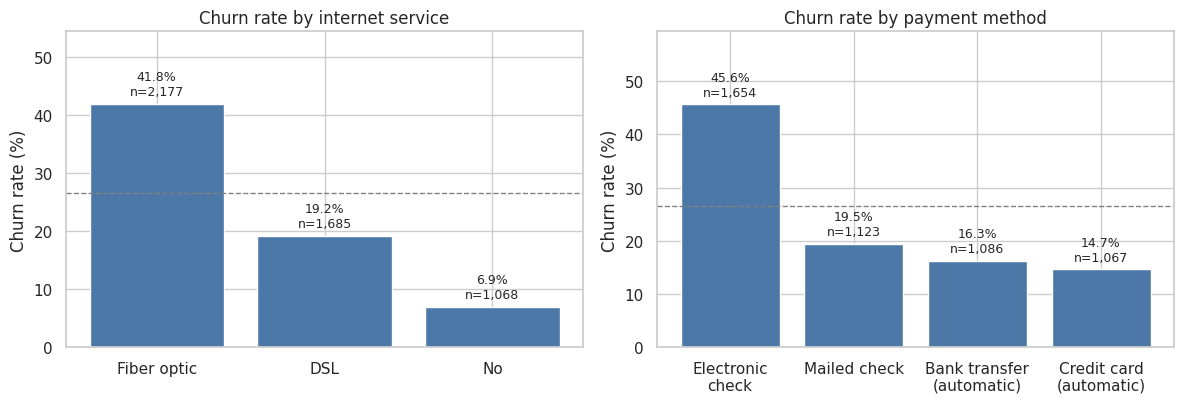

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
rate_bar(ax[0], "InternetService", title="Churn rate by internet service")
rate_bar(ax[1], "PaymentMethod", title="Churn rate by payment method")
plt.tight_layout(); plt.show()

**Business insight.** Fiber-optic customers (~42%) churn at more than twice the rate of DSL customers (~19%), which points to a product-quality, price or competition problem in the fiber segment, and it is worth investigating rather than just discounting. Electronic-check payers churn at ~46%, against roughly 15-20% for every other payment method. Customers who must actively pay every month have a recurring moment at which to reconsider; moving them to automatic payment is a cheap retention lever.

### 2.6 Churn by add-on services (customers with internet)

,Has service,Does not have service
service,,
OnlineSecurity,14.7,42.0
OnlineBackup,21.6,40.3
DeviceProtection,22.9,39.2
TechSupport,15.4,41.9
StreamingTV,30.3,33.6
StreamingMovies,30.2,33.7


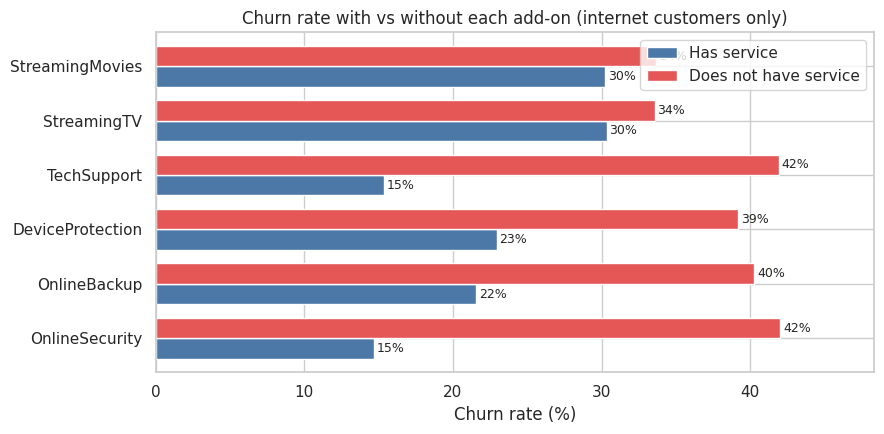

In [18]:
internet = eda[eda["InternetService"] != "No"]
rows = []
for c in ADDON_COLS:
    r = internet.groupby(c)["Churn"].mean() * 100
    rows.append({"service": c, "Has service": r["Yes"], "Does not have service": r["No"]})
svc = pd.DataFrame(rows).set_index("service")

ax = svc.plot(kind="barh", figsize=(9, 4.5), color=["#4C78A8", "#E45756"], width=0.75)
ax.set_xlabel("Churn rate (%)"); ax.set_ylabel("")
ax.set_title("Churn rate with vs without each add-on (internet customers only)")
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.0f%%", padding=2, fontsize=9)
ax.set_xlim(0, svc.values.max() * 1.15)
plt.tight_layout(); plt.show()
svc.round(1)

**Business insight.** Protective services, above all *online security* and *tech support* (and to a lesser extent backup and device protection), are associated with far lower churn than not having them. Streaming services show little difference. This suggests that "sticky" services that make customers feel supported are what matters, so bundling security or support into plans is a plausible retention lever. (This is an association, not proof of cause: engaged customers may simply be more likely to buy add-ons.)

### 2.7 Customer demographics

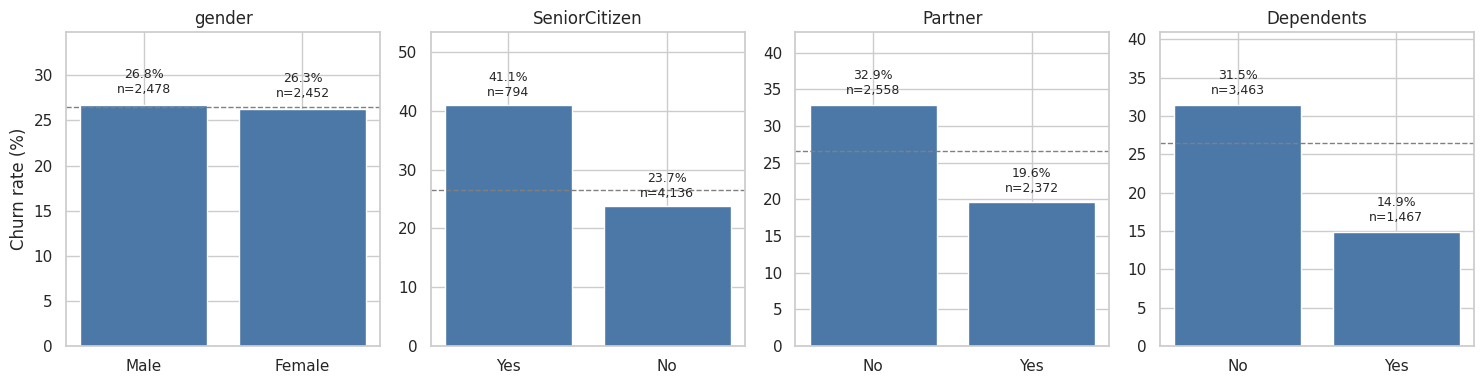

In [19]:
demo = eda.assign(SeniorCitizen=eda["SeniorCitizen"].map({0: "No", 1: "Yes"}))
fig, ax = plt.subplots(1, 4, figsize=(15, 4))
for a, col in zip(ax, ["gender", "SeniorCitizen", "Partner", "Dependents"]):
    rate_bar(a, col, data=demo, title=col)
    if col != "gender": a.set_ylabel("")
ax[0].set_ylabel("Churn rate (%)")
plt.tight_layout(); plt.show()

**Business insight.** Gender makes no meaningful difference, so it will not help a model and should not drive any targeting. Senior citizens churn at about 1.7 times the rate of other customers (~41% vs ~24%), while customers with a partner or dependents are noticeably more loyal. Household situation is a modest signal; contract, tenure and services are far stronger.

### 2.8 Correlations and the tenure–charges relationship

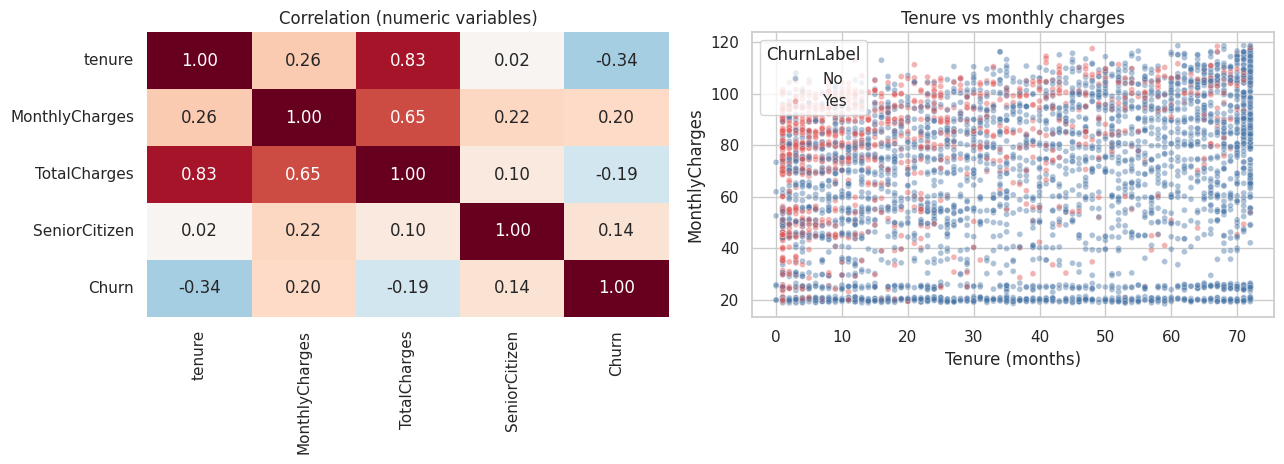

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
corr = eda[["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "Churn"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax[0], cbar=False)
ax[0].set_title("Correlation (numeric variables)")

sns.scatterplot(data=eda, x="tenure", y="MonthlyCharges", hue="ChurnLabel", palette=PALETTE,
                alpha=0.45, s=18, ax=ax[1])
ax[1].set_title("Tenure vs monthly charges"); ax[1].set_xlabel("Tenure (months)")
plt.tight_layout(); plt.show()

**Business insight.** Tenure has the strongest correlation with churn (about -0.34: longer relationship, lower churn), and higher `MonthlyCharges` correlates positively (about +0.20). `TotalCharges` correlates negatively with churn (about -0.19) only because it is strongly tied to tenure (about 0.83; it is essentially tenure × price), so it carries little independent information. The scatter shows the churn cluster sitting at short tenure *and* mid-to-high monthly bills: the profile of a recently acquired, higher-paying customer on a flexible plan.

### 2.9 EDA summary

1. **Who churns:** new customers (first year), on month-to-month contracts, with fiber optic, paying by electronic check, without security/support add-ons.
2. **Who stays:** long-tenure customers on one- or two-year contracts, with automatic payment and protective add-ons.
3. **What does not matter:** gender.
4. **Modelling implications:** imbalanced target → stratified split, class weighting and non-accuracy metrics; `TotalCharges` is largely redundant with tenure × price.

## 3. Feature engineering
Four features are built inside `CleanAndEngineer` (`src/features.py`) so training and the API share the code. All of them are **row-wise and stateless**: they use only the customer's own values, so no information can leak from the test set.

| Feature | How it is created | Why it may help |
|---|---|---|
| `tenure_group` | Buckets tenure into `0-12`, `13-24`, `25-48`, `49+` months | EDA shows churn drops in steps over the customer lifecycle. A named lifecycle stage gives the model an explicit, interpretable segment. |
| `num_addons` | Count of "Yes" among the 6 optional services (security, backup, device protection, tech support, streaming TV/movies) | Measures how embedded the customer is in the product. Only "Yes" counts, so the redundant "No internet service" level is not mistaken for a subscription. |
| `avg_monthly_spend` | `TotalCharges / tenure` (uses `MonthlyCharges` when tenure = 0) | The customer's *historical* average bill. Comparing it with the *current* `MonthlyCharges` reveals recent price increases or upgrades. |
| `autopay` | 1 if payment method is bank transfer or credit card (automatic), else 0 | EDA shows electronic-check payers churn most. A simple flag for "pays without having to act each month" captures payment friction. |

In [21]:
fe = CleanAndEngineer(add_features=True)
train_fe = fe.fit_transform(X_train)
new_cols = ["tenure_group", "num_addons", "avg_monthly_spend", "autopay"]
display(train_fe[["tenure", "TotalCharges", "MonthlyCharges", "PaymentMethod"] + new_cols].head(8).round(2))

# How different is the historical average bill from the current one?
gap = (train_fe["MonthlyCharges"] - train_fe["avg_monthly_spend"]).abs() / train_fe["MonthlyCharges"]
print(f"Customers whose current bill differs from their historical average by >10%: {(gap > 0.10).mean():.1%}")

,tenure,TotalCharges,MonthlyCharges,PaymentMethod,tenure_group,num_addons,avg_monthly_spend,autopay
5557,5,384.25,80.20,Electronic check,0-12,1,76.85,0
2270,3,220.95,86.85,Electronic check,0-12,2,73.65,0
6930,3,216.75,75.15,Credit card (automatic),0-12,0,72.25,1
2257,60,4847.05,80.55,Credit card (automatic),49+,4,80.78,1
898,12,1120.95,98.90,Bank transfer (automatic),0-12,4,93.41,1
3828,65,1319.95,19.35,Bank transfer (automatic),49+,0,20.31,1
2147,18,348.80,19.00,Electronic check,13-24,0,19.38,0
3149,8,504.05,64.10,Mailed check,0-12,3,63.01,0


Customers whose current bill differs from their historical average by >10%: 5.3%


Customers with 0 add-ons: 1,538 | of which have no internet service: 1,068
Churn rate at 0 add-ons, internet customers only: 51.1%


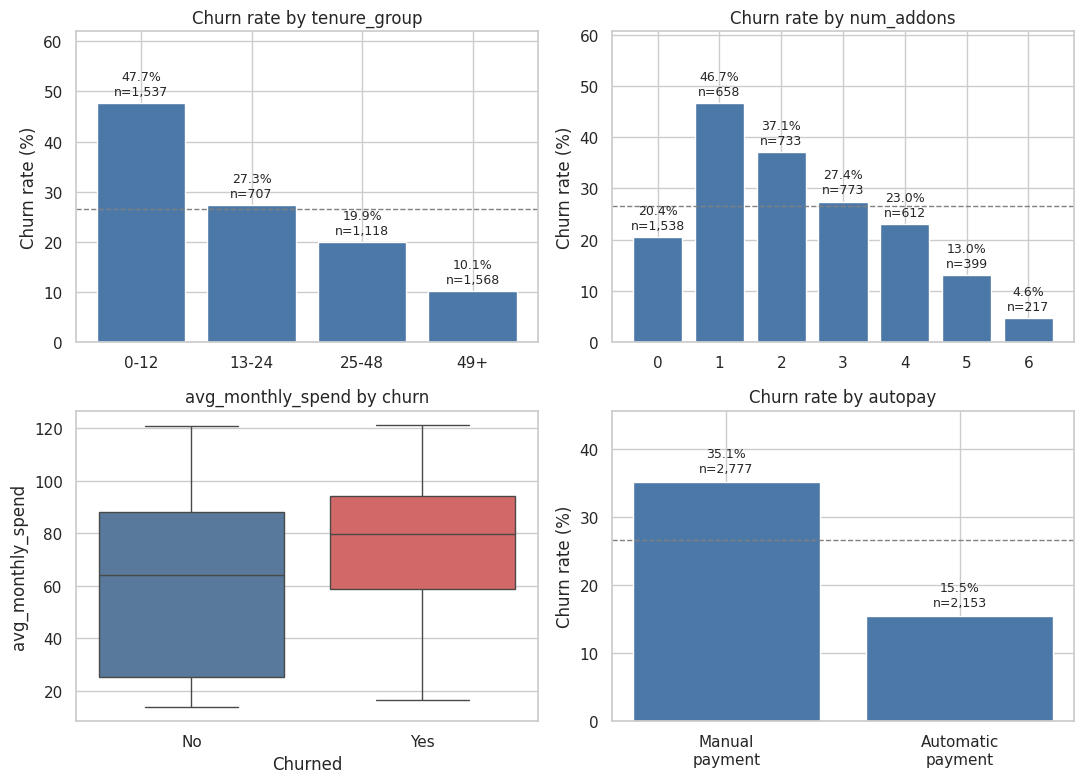

In [22]:
fe_eda = train_fe.assign(Churn=y_train)

zero = fe_eda[fe_eda["num_addons"] == 0]
print(f"Customers with 0 add-ons: {len(zero):,} | of which have no internet service: {(zero['InternetService'] == 'No').sum():,}")
print("Churn rate at 0 add-ons, internet customers only: "
      f"{zero.loc[zero['InternetService'] != 'No', 'Churn'].mean():.1%}")

fig, ax = plt.subplots(2, 2, figsize=(11, 8))

rate_bar(ax[0, 0], "tenure_group", data=fe_eda, order=["0-12", "13-24", "25-48", "49+"], title="Churn rate by tenure_group")
rate_bar(ax[0, 1], "num_addons", data=fe_eda, order=sorted(fe_eda["num_addons"].unique()), title="Churn rate by num_addons")

sns.boxplot(data=fe_eda.assign(ChurnLabel=fe_eda["Churn"].map({0: "No", 1: "Yes"})), x="ChurnLabel", y="avg_monthly_spend",
            order=["No", "Yes"], hue="ChurnLabel", palette=PALETTE, legend=False, ax=ax[1, 0])
ax[1, 0].set_title("avg_monthly_spend by churn"); ax[1, 0].set_xlabel("Churned")

ap = fe_eda.assign(autopay=fe_eda["autopay"].map({0: "Manual payment", 1: "Automatic payment"}))
rate_bar(ax[1, 1], "autopay", data=ap, order=["Manual payment", "Automatic payment"], title="Churn rate by autopay")
plt.tight_layout(); plt.show()

**Reading the charts.** `tenure_group` and `autopay` show a clear churn gradient (48% down to 10% across tenure groups; 35% for manual vs 16% for automatic payment). `avg_monthly_spend` is higher for churners. `num_addons` looks odd at first: the 0 bar (20%) is *lower* than the 1 bar (47%). The printout above explains why: most customers with 0 add-ons have **no internet service at all** and rarely churn. Among customers who do have internet, churn falls steadily with every add-on, from about half at 0 add-ons to under 5% with all six. A tree can separate the two groups using `InternetService`, but this shows the feature needs to be read together with it. Whether these features improve the *model* is tested with a with/without comparison in section 4, because a tree can often re-discover such splits from the raw columns.

## 4. Model development
### 4.1 How models are compared
All models are Decision Trees inside the same pipeline. To keep the test set untouched they are compared with **stratified 5-fold cross-validation on the training set**. Metrics are for the *churn* class. `train_f1` next to `cv_f1` exposes overfitting: a large gap means the tree memorised the training data.

In [23]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = {"accuracy": "accuracy", "precision": "precision", "recall": "recall", "f1": "f1", "roc_auc": "roc_auc"}

def cv_summary(name, pipe):
    res = cross_validate(pipe, X_train, y_train, cv=skf, scoring=SCORING, return_train_score=True)
    row = {"model": name}
    for m in SCORING:
        row[f"cv_{m}"] = res[f"test_{m}"].mean()
    row["train_f1"] = res["train_f1"].mean()
    return row

def dt(**kw):
    return DecisionTreeClassifier(random_state=RANDOM_STATE, **kw)

PRUNED = dict(max_depth=5, min_samples_leaf=50)
experiments = [
    ("1  Unrestricted tree, raw features",              build_pipeline(dt(), add_features=False)),
    ("2  Unrestricted tree, + engineered features",     build_pipeline(dt(), add_features=True)),
    ("3  Pruned tree (depth 5, leaf 50), raw",          build_pipeline(dt(**PRUNED), add_features=False)),
    ("4  Pruned tree, + engineered features",           build_pipeline(dt(**PRUNED), add_features=True)),
    ("5  Pruned + balanced weights, raw",               build_pipeline(dt(class_weight="balanced", **PRUNED), add_features=False)),
    ("6  Pruned + balanced weights, + features",        build_pipeline(dt(class_weight="balanced", **PRUNED), add_features=True)),
]
cv_rows = [cv_summary(n, p) for n, p in experiments]
pd.DataFrame(cv_rows).set_index("model").round(3)

,cv_accuracy,cv_precision,cv_recall,cv_f1,cv_roc_auc,train_f1
model,,,,,,
"1 Unrestricted tree, raw features",0.731,0.493,0.511,0.502,0.662,0.997
"2 Unrestricted tree, + engineered features",0.734,0.499,0.523,0.510,0.668,0.997
"3 Pruned tree (depth 5, leaf 50), raw",0.790,0.638,0.497,0.554,0.826,0.582
"4 Pruned tree, + engineered features",0.791,0.630,0.527,0.570,0.826,0.595
"5 Pruned + balanced weights, raw",0.735,0.502,0.780,0.610,0.828,0.636
"6 Pruned + balanced weights, + features",0.721,0.484,0.788,0.600,0.827,0.633


### 4.2 What the comparison shows

**1. The unrestricted tree overfits badly (rows 1-2).** It scores an F1 of ~0.997 on the data it was trained on but only ~0.50 in cross-validation (CV ROC-AUC 0.66): it has memorised the training customers. Limiting the tree (`max_depth=5`, `min_samples_leaf=50`, rows 3-4) lifts CV ROC-AUC to 0.83 and closes the train/CV gap (train F1 ~0.58-0.60 vs CV F1 ~0.55-0.57).

**2. Class weighting is what moves recall (rows 5-6).** The pruned tree on its own has decent precision (~0.63) but recall of only ~0.50: it misses about half of the churners. Adding `class_weight="balanced"` raises recall to ~0.78-0.79 at the cost of precision (~0.48-0.50) and lifts F1 to ~0.60-0.61. Accuracy *falls* (0.79 to 0.72-0.74), which is expected: accuracy rewards ignoring the minority class.

**3. The engineered features do not reliably improve a tree.** Comparing rows 1 vs 2, 3 vs 4 and 5 vs 6, CV F1 changes by +0.008, +0.016 and -0.010. The fold-to-fold standard deviation of F1 is about 0.02, so all three differences are within noise. That is plausible: a tree can already split on `tenure` and `Contract` by itself, so re-encoding them adds little. The features are kept (they are cheap, show no measurable harm and make segments easier to communicate), but they should not be presented as a proven accuracy gain.

### 4.3 Hyper-parameter tuning (bonus)
A grid search over depth, leaf size, split criterion and class weight, scored by **F1 on the churn class**. F1 balances catching churners against false alarms, so the search cannot "win" by flagging everyone (recall alone would allow that). The search runs only on the training set with the same 5 folds.

In [24]:
param_grid = {
    "clf__max_depth": [3, 4, 5, 6, 8, 10, None],
    "clf__min_samples_leaf": [1, 10, 25, 50, 100],
    "clf__criterion": ["gini", "entropy"],
    "clf__class_weight": [None, "balanced"],
}
def simplest_near_best(cv_results, tol=0.002):
    """Refit rule: among all settings whose mean CV F1 is within `tol` of the best, pick the shallowest tree.
    Differences that small are far below the fold-to-fold noise, so simpler is the better bet."""
    res = pd.DataFrame(cv_results)
    near = res[res["mean_test_score"] >= res["mean_test_score"].max() - tol].copy()
    near["depth_rank"] = near["param_clf__max_depth"].map(lambda d: 10**6 if d is None else d)
    return int(near.sort_values(["depth_rank", "rank_test_score"]).index[0])

grid = GridSearchCV(build_pipeline(dt(), add_features=True), param_grid, cv=skf,
                    scoring="f1", refit=simplest_near_best)
grid.fit(X_train, y_train)

res = pd.DataFrame(grid.cv_results_)
i = grid.best_index_
print(f"Searched {len(res)} combinations x 5 folds")
print("Selected parameters:", {k.replace("clf__", ""): v for k, v in grid.best_params_.items()})
print(f"CV F1 of selected setting : {res.loc[i, 'mean_test_score']:.4f}")
print(f"Best CV F1 of any setting : {res['mean_test_score'].max():.4f}")
print(f"Fold-to-fold std of F1    : {res.loc[i, 'std_test_score']:.3f}  (so gaps below ~0.01 are noise)")

top = (res.assign(selected=(res.index == i)).sort_values("rank_test_score").head(8)
       [["param_clf__max_depth", "param_clf__min_samples_leaf", "param_clf__criterion",
         "param_clf__class_weight", "mean_test_score", "std_test_score", "selected"]]
       .rename(columns=lambda c: c.replace("param_clf__", "")))
top.round(4)

Searched 140 combinations x 5 folds
Selected parameters: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 100}
CV F1 of selected setting : 0.6152
Best CV F1 of any setting : 0.6152
Fold-to-fold std of F1    : 0.023  (so gaps below ~0.01 are noise)


,max_depth,min_samples_leaf,criterion,class_weight,mean_test_score,std_test_score,selected
124,6,100,entropy,balanced,0.6152,0.0231,False
139,None,100,entropy,balanced,0.6152,0.0231,False
134,10,100,entropy,balanced,0.6152,0.0231,False
129,8,100,entropy,balanced,0.6152,0.0231,False
84,5,100,gini,balanced,0.6152,0.0233,True
104,None,100,gini,balanced,0.6138,0.0230,False
89,6,100,gini,balanced,0.6138,0.0230,False
94,8,100,gini,balanced,0.6138,0.0230,False


### 4.4 Extra comparison: Random Forest (bonus)
A Random Forest is included only as a *reference point* for how much accuracy a single interpretable tree gives up. The deliverable is a Decision Tree.

In [25]:
rf = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=20,
                            class_weight="balanced_subsample", random_state=RANDOM_STATE)
cv_rows.append(cv_summary("7  Tuned tree (GridSearchCV, F1)", grid.best_estimator_))
cv_rows.append(cv_summary("8  Random Forest (reference only)", build_pipeline(rf, add_features=True)))

cv_table = pd.DataFrame(cv_rows).set_index("model")
cv_table.round(3)

,cv_accuracy,cv_precision,cv_recall,cv_f1,cv_roc_auc,train_f1
model,,,,,,
"1 Unrestricted tree, raw features",0.731,0.493,0.511,0.502,0.662,0.997
"2 Unrestricted tree, + engineered features",0.734,0.499,0.523,0.510,0.668,0.997
"3 Pruned tree (depth 5, leaf 50), raw",0.790,0.638,0.497,0.554,0.826,0.582
"4 Pruned tree, + engineered features",0.791,0.630,0.527,0.570,0.826,0.595
"5 Pruned + balanced weights, raw",0.735,0.502,0.780,0.610,0.828,0.636
"6 Pruned + balanced weights, + features",0.721,0.484,0.788,0.600,0.827,0.633
"7 Tuned tree (GridSearchCV, F1)",0.740,0.507,0.783,0.615,0.827,0.631
8 Random Forest (reference only),0.756,0.528,0.778,0.629,0.847,0.665


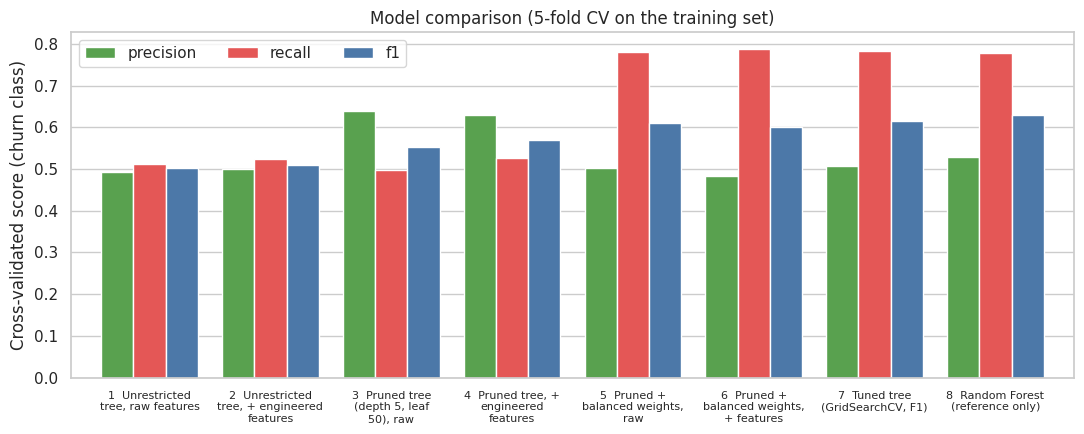

In [26]:
plot_df = cv_table[["cv_precision", "cv_recall", "cv_f1"]].rename(columns=lambda c: c.replace("cv_", ""))
ax = plot_df.plot(kind="bar", figsize=(11, 4.5), width=0.8, color=["#59A14F", "#E45756", "#4C78A8"])
ax.set_xticklabels([textwrap.fill(t.get_text(), 18) for t in ax.get_xticklabels()], rotation=0, fontsize=8)
ax.set_ylabel("Cross-validated score (churn class)"); ax.set_xlabel("")
ax.set_title("Model comparison (5-fold CV on the training set)")
ax.legend(loc="upper left", ncol=3)
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

### 4.5 Final model selection

**Chosen model: Decision Tree with `criterion="gini"`, `max_depth=5`, `min_samples_leaf=100`, `class_weight="balanced"`, inside the full cleaning + feature + encoding pipeline.**

Why this one:

1. **It fits the business goal.** It has the best cross-validated F1 of any Decision Tree configuration (0.615) and a CV recall of ~0.78, against ~0.50 for the same tree without class weights.
2. **It generalises.** Train F1 (0.63) is close to CV F1 (0.615), whereas the unrestricted tree scored 0.997 on training data and 0.50 in CV.
3. **It is as simple as it can be.** Several settings tie on F1 (differences of 0.0001-0.002, against a fold-to-fold standard deviation of 0.023). Instead of trusting an arbitrary tie-break, the refit rule picks the *shallowest* tree among the near-ties. A depth-5, 24-leaf tree can be shown on one page and explained to the retention team.
4. **The test set played no part in the choice.** Everything above uses cross-validation on the training data only.

The Random Forest (row 8) is only modestly better (CV F1 0.629, ROC-AUC 0.847). That ~0.014 F1 gain would cost the interpretability this brief is built around, so it stays a reference point, not the deliverable.

In [27]:
final_model = grid.best_estimator_          # already refitted on the full training set
tree = final_model.named_steps["clf"]
print("Final model : Decision Tree inside a full preprocessing pipeline")
print("Parameters  :", {k.replace('clf__', ''): v for k, v in grid.best_params_.items()})
print(f"Tree size   : depth {tree.get_depth()}, {tree.get_n_leaves()} leaves")

Final model : Decision Tree inside a full preprocessing pipeline
Parameters  : {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 100}
Tree size   : depth 5, 24 leaves


## 5. Model evaluation
This is the **first and only time the test set is used to score the final model.**

In [28]:
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

test_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba),
}
display(pd.Series(test_metrics).round(3).to_frame("test set"))
print(f"For reference, always predicting 'No' would score {1 - y_test.mean():.3f} accuracy but 0.000 recall.")

,test set
Accuracy,0.711
Precision,0.474
Recall,0.822
F1 score,0.601
ROC-AUC,0.832


For reference, always predicting 'No' would score 0.735 accuracy but 0.000 recall.


              precision    recall  f1-score   support

      Stayed      0.912     0.671     0.773      1552
     Churned      0.474     0.822     0.601       561

    accuracy                          0.711      2113
   macro avg      0.693     0.746     0.687      2113
weighted avg      0.796     0.711     0.728      2113



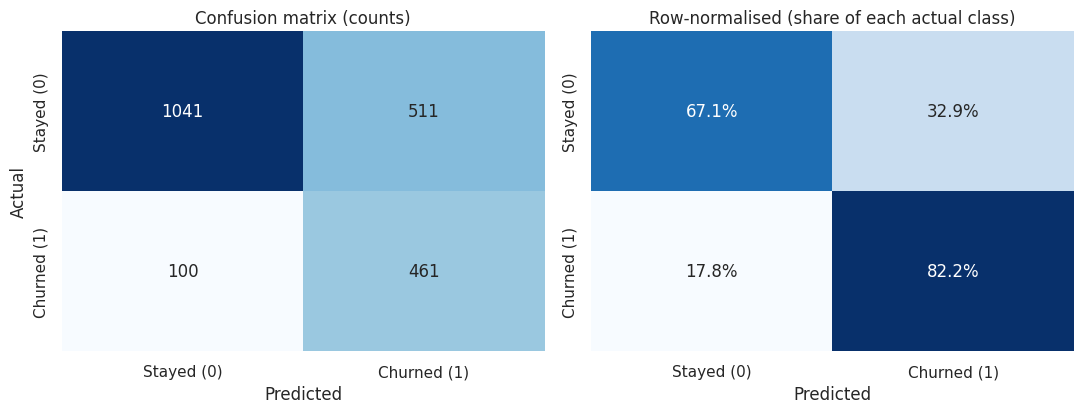

In [29]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(1, 2, figsize=(11, 4.3))
labels = ["Stayed (0)", "Churned (1)"]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=labels, yticklabels=labels, ax=ax[0])
ax[0].set_title("Confusion matrix (counts)"); ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("Actual")
sns.heatmap(cm / cm.sum(axis=1, keepdims=True), annot=True, fmt=".1%", cmap="Blues", cbar=False,
            xticklabels=labels, yticklabels=labels, ax=ax[1])
ax[1].set_title("Row-normalised (share of each actual class)"); ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("")
plt.tight_layout(); plt.show()

print(classification_report(y_test, y_pred, target_names=["Stayed", "Churned"], digits=3))

In [30]:
churners = tp + fn
flagged = tp + fp
print(f"Customers in test set          : {len(y_test):,} ({churners} actual churners, {churners/len(y_test):.1%})")
print(f"Churners caught (recall)       : {tp} of {churners} = {tp/churners:.1%}")
print(f"Churners missed (false neg.)   : {fn}")
print(f"Customers flagged as at-risk   : {flagged} = {flagged/len(y_test):.1%} of all customers")
print(f"  of which real churners       : {tp} = {tp/flagged:.1%} (precision)")
print(f"  of which false alarms        : {fp}")
print(f"Lift over random targeting     : {tp/flagged/y_test.mean():.2f}x  (churn rate among flagged vs the {y_test.mean():.1%} base rate)")
print(f"Mean predicted churn probability: {y_proba.mean():.3f} vs actual churn rate {y_test.mean():.3f}  (class weights inflate the scores)")
print(f"Contacting {flagged/len(y_test):.0%} of customers at random would reach ~{flagged/len(y_test):.0%} of churners; the model reaches {tp/churners:.0%}.")

Customers in test set          : 2,113 (561 actual churners, 26.5%)
Churners caught (recall)       : 461 of 561 = 82.2%
Churners missed (false neg.)   : 100
Customers flagged as at-risk   : 972 = 46.0% of all customers
  of which real churners       : 461 = 47.4% (precision)
  of which false alarms        : 511
Lift over random targeting     : 1.79x  (churn rate among flagged vs the 26.5% base rate)
Mean predicted churn probability: 0.411 vs actual churn rate 0.265  (class weights inflate the scores)
Contacting 46% of customers at random would reach ~46% of churners; the model reaches 82%.


In [31]:
# Reference only: the same evaluation for the plain, unrestricted tree (NOT used to choose the model)
ref = experiments[1][1].fit(X_train, y_train)
ref_pred = ref.predict(X_test)
pd.DataFrame({
    "Unrestricted tree (reference)": [accuracy_score(y_test, ref_pred), precision_score(y_test, ref_pred),
                                      recall_score(y_test, ref_pred), f1_score(y_test, ref_pred)],
    "Final tuned tree": [test_metrics["Accuracy"], test_metrics["Precision"], test_metrics["Recall"], test_metrics["F1 score"]],
}, index=["Accuracy", "Precision", "Recall", "F1 score"]).round(3)

,Unrestricted tree (reference),Final tuned tree
Accuracy,0.722,0.711
Precision,0.477,0.474
Recall,0.488,0.822
F1 score,0.483,0.601


In [32]:
# Illustration only: how the precision/recall trade-off moves with the alert threshold.
# The final model keeps the default 0.5 threshold; this table is NOT used to select anything.
rows = []
for thr in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    p = (y_proba >= thr).astype(int)
    rows.append({"threshold": thr, "flagged_%": p.mean() * 100,
                 "precision": precision_score(y_test, p, zero_division=0),
                 "recall": recall_score(y_test, p), "f1": f1_score(y_test, p)})
pd.DataFrame(rows).set_index("threshold").round(3)

,flagged_%,precision,recall,f1
threshold,,,,
0.2,66.446,0.384,0.961,0.549
0.3,51.301,0.449,0.868,0.592
0.4,49.314,0.463,0.859,0.601
0.5,46.001,0.474,0.822,0.601
0.6,30.999,0.568,0.663,0.612
0.7,23.663,0.640,0.570,0.603


### 5.1 Reading the results

- **Test performance matches cross-validation** (F1 0.601 on test vs 0.615 in CV), so there is no sign of overfitting or leakage.
- **Accuracy (0.711) is *below* the 0.735 you get by always predicting "No"**, yet the model is far more useful: the "always No" rule finds no churners, this model finds 82% of them. This is why accuracy is not the metric to judge it by.
- **Compared with the plain unrestricted tree**, recall on the test set rises from 0.49 to 0.82 while precision stays about the same (~0.47-0.48).

**Confusion matrix in business terms** (2,113 test customers, 561 of whom actually churn):

| | Meaning | Count |
|---|---|---|
| True positives | Churners flagged, so the retention team *can* act | 461 |
| False negatives | Churners the model missed: lost silently | 100 |
| False positives | Loyal customers flagged: an unneeded offer or call | 511 |
| True negatives | Loyal customers correctly left alone | 1,041 |

Targeting the 46% of customers the model flags reaches 82% of churners. Among the flagged, 47% really churn, 1.8 times the 26.5% base rate. The threshold table shows the dial the retention team can turn: at a 0.6 cut-off it would contact 31% of customers, with precision 0.57 and recall 0.66.

### 5.2 Precision or recall for a telecom retention team?

**Recall should be the priority, with precision as a guard-rail.**

- **The two mistakes cost very different amounts.** A missed churner (false negative) is a lost customer: the recurring revenue for the rest of their lifetime plus the cost of acquiring a replacement. A false alarm (false positive) costs a retention offer, a discount or a phone call, which is small and bounded.
- **The break-even rule.** Contacting a customer pays off when `P(churn) × offer success rate × value of a saved customer > cost of the contact`. Example with **hypothetical** figures (replace them with the company's own): if a saved customer is worth 20 times the cost of an offer and 25% of offers work, the break-even precision is 1 / (20 × 0.25) = 20%. The model's 47% is well above that, so the campaign is profitable even though more than half of the alerts are false alarms.
- **Why not recall alone?** A model can reach 100% recall by flagging everybody, which wastes budget and annoys loyal customers. Precision matters when contact capacity or discount budget is limited, so models were selected on **F1**, which balances the two, and the alert threshold can be raised if the team can only handle a smaller list.

## 6. Model interpretation
### 6.1 Feature importance
The tree's importance is the total reduction in impurity a feature brings across all its splits. One-hot columns are added back together per *original* feature, so `Contract_Month-to-month` and `Contract_Two year` count towards `Contract`.

Features used by the tree at all: 15 of 52 columns
Importance of the engineered features: {'tenure_group': 0.0, 'num_addons': 0.0, 'avg_monthly_spend': 0.008, 'autopay': 0.003}
Contract + tenure + InternetService together: 84.5%


,importance
Contract,0.631
tenure,0.109
InternetService,0.104
MonthlyCharges,0.044
OnlineSecurity,0.033
TotalCharges,0.024
TechSupport,0.015
PaymentMethod,0.015


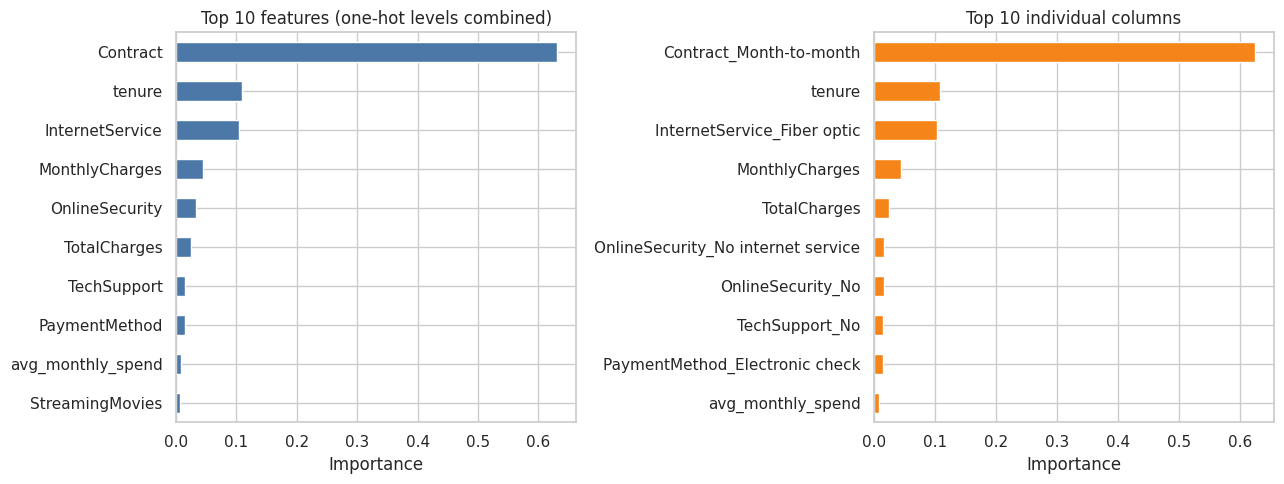

In [33]:
prep = final_model.named_steps["prep"]
feat_names = prep.get_feature_names_out()

# map every one-hot column back to the original feature it came from
ohe = prep.named_transformers_["cat"]
cat_cols = prep.transformers_[0][2]
source = {f"{col}_{cat}": col for col, cats in zip(cat_cols, ohe.categories_) for cat in cats}

imp = pd.Series(tree.feature_importances_, index=feat_names)
by_feature = imp.groupby(lambda n: source.get(n, n)).sum().sort_values(ascending=False)
by_level = imp.sort_values(ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
by_feature.head(10)[::-1].plot(kind="barh", color="#4C78A8", ax=ax[0])
ax[0].set_title("Top 10 features (one-hot levels combined)"); ax[0].set_xlabel("Importance")
by_level.head(10)[::-1].plot(kind="barh", color="#F58518", ax=ax[1])
ax[1].set_title("Top 10 individual columns"); ax[1].set_xlabel("Importance")
plt.tight_layout(); plt.show()

print(f"Features used by the tree at all: {(imp > 0).sum()} of {len(imp)} columns")
eng = ["tenure_group", "num_addons", "avg_monthly_spend", "autopay"]
print("Importance of the engineered features:", by_feature.reindex(eng).fillna(0).round(3).to_dict())
print(f"Contract + tenure + InternetService together: {by_feature[['Contract', 'tenure', 'InternetService']].sum():.1%}")
by_feature.head(8).round(3).to_frame("importance")

### 6.2 Decision tree visualisation
Top three levels of the final tree. Each box shows the split rule, the share of training customers reaching it (`samples`), the class proportions (`value`, weighted by class weights when `balanced`), and the predicted class. **Orange leans "Stay", blue leans "Churn"**; the darker the box, the purer the node.

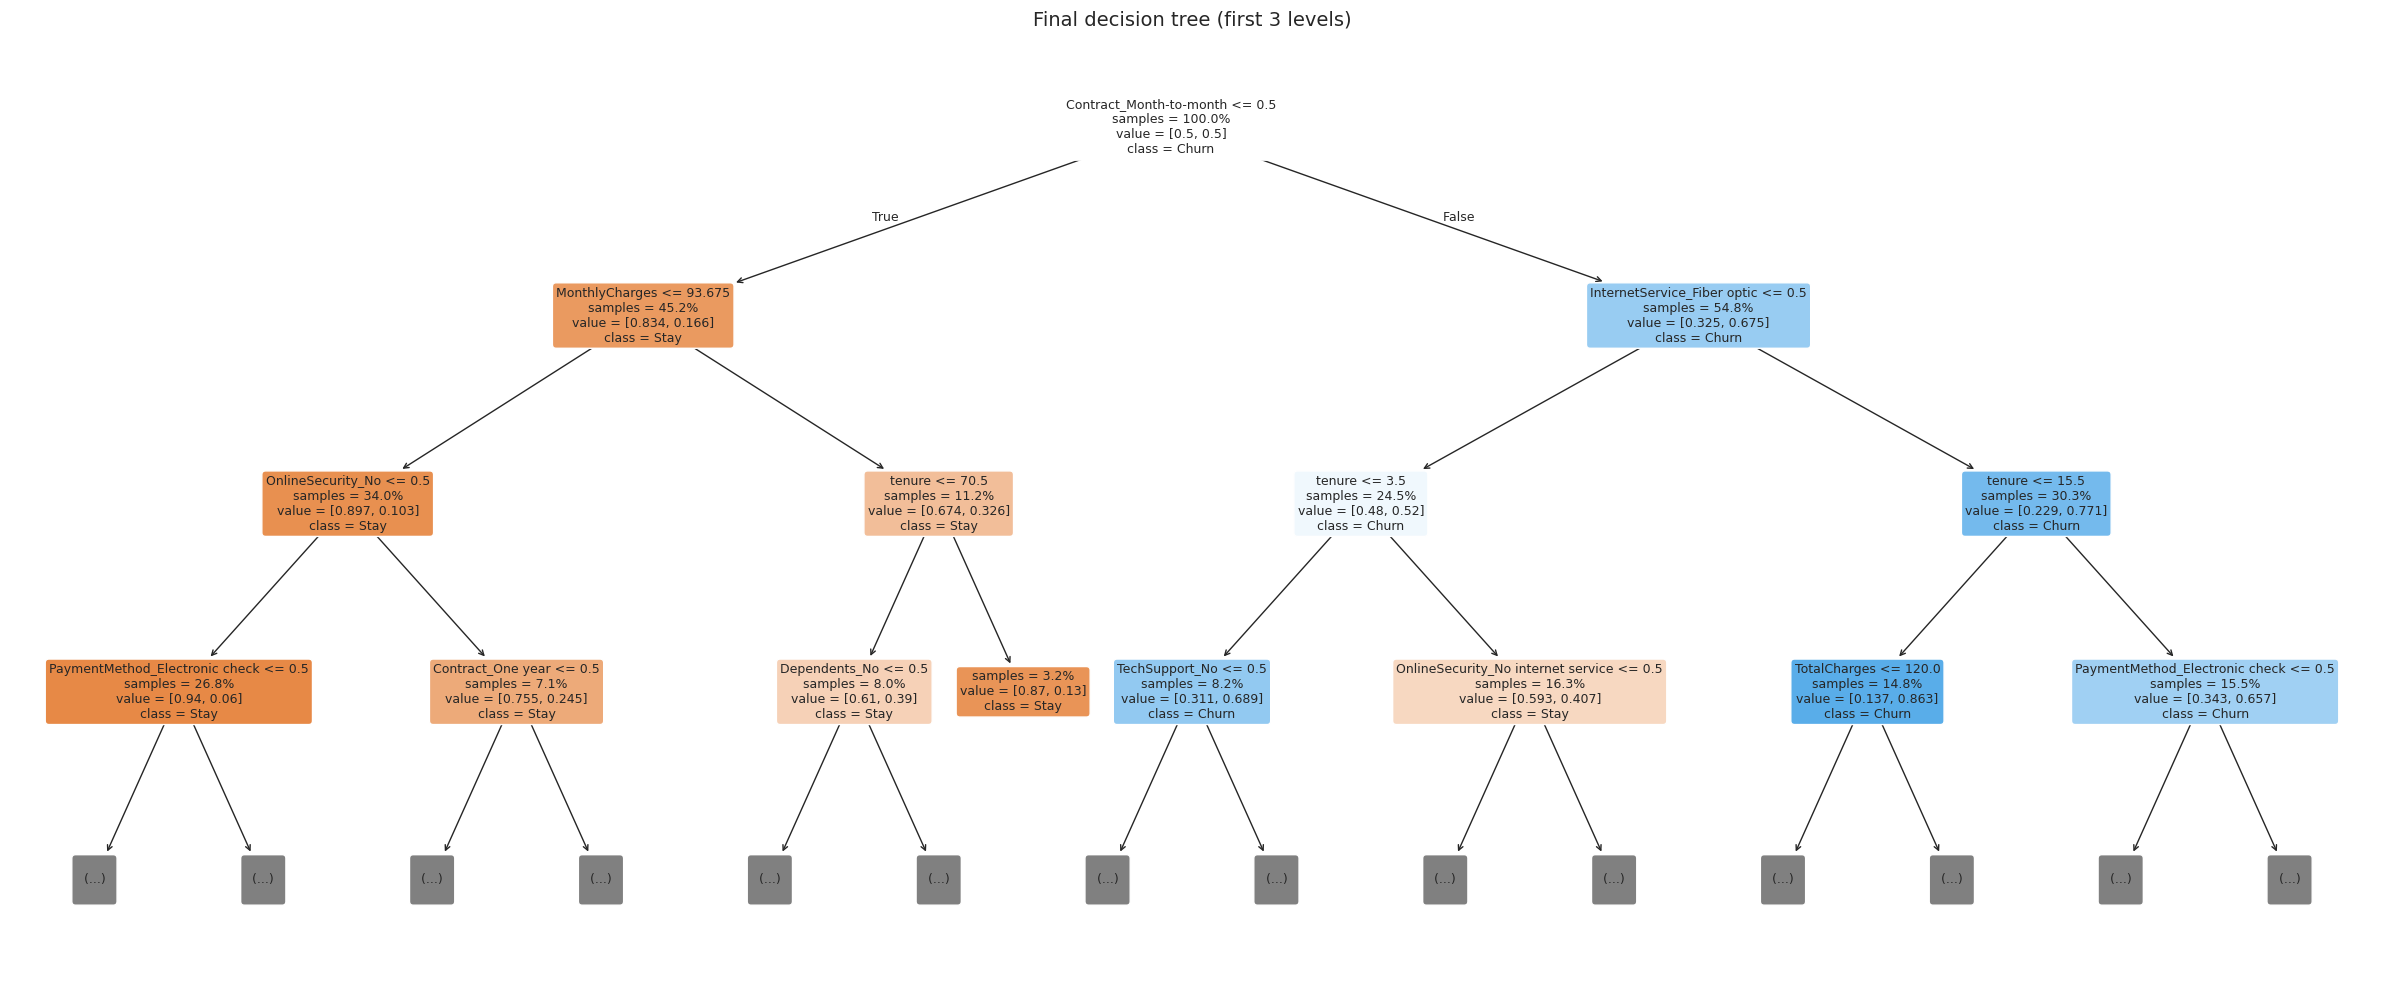

In [34]:
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(tree, max_depth=3, feature_names=list(feat_names), class_names=["Stay", "Churn"],
          filled=True, rounded=True, impurity=False, proportion=True, fontsize=9, ax=ax)
ax.set_title("Final decision tree (first 3 levels)", fontsize=14)
plt.tight_layout(); plt.show()

In [35]:
# The same first levels as readable rules
print(export_text(tree, feature_names=list(feat_names), max_depth=3, show_weights=False))

|--- Contract_Month-to-month <= 0.50
|   |--- MonthlyCharges <= 93.67
|   |   |--- OnlineSecurity_No <= 0.50
|   |   |   |--- PaymentMethod_Electronic check <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- PaymentMethod_Electronic check >  0.50
|   |   |   |   |--- class: 0
|   |   |--- OnlineSecurity_No >  0.50
|   |   |   |--- Contract_One year <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- Contract_One year >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |--- MonthlyCharges >  93.67
|   |   |--- tenure <= 70.50
|   |   |   |--- Dependents_No <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- Dependents_No >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- tenure >  70.50
|   |   |   |--- class: 0
|--- Contract_Month-to-month >  0.50
|   |--- InternetService_Fiber optic <= 0.50
|   |   |--- tenure <= 3.50
|   |   |   |--- TechSupport_No <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- TechSupport_No >  0.50
| 

### 6.3 Key findings: what drives the predictions

- **Three features do most of the work.** `Contract` (0.63), `tenure` (0.11) and `InternetService` (0.10) together account for about 84% of the model's importance. Only 15 of the 52 encoded columns are used at all.
- **Reading the tree.** The first split separates month-to-month customers from one- and two-year contracts. Longer contracts (45% of customers) end up mostly in "Stay" boxes (class-weighted churn share of about 17%). Month-to-month customers (55%) start at about 68%. Within them, **fiber-optic customers with tenure under ~15 months** form the highest-risk pocket (about 77%), while non-fiber month-to-month customers split on very short tenure (under ~4 months). (`value` in the boxes is re-weighted by the class weights, so it is higher than the raw churn rate.)
- **Supporting signals.** Monthly charges, missing online security or tech support, and electronic-check payment refine the predictions further down the tree, matching the EDA.
- **Consistent with the EDA.** The tree recovers the profile found earlier: new, month-to-month, fiber, higher-bill customers without support add-ons. Gender is not used.
- **The engineered features are barely used** (`avg_monthly_spend` 0.008, `autopay` 0.003, the other two 0.0): the raw columns already carry the same information for a tree, in line with the with/without comparison. They would matter more for a linear model, which cannot create threshold splits on its own.
- **Caution.** Importance says what the model *uses*, not which way it pushes or why: contract type is associated with churn, but changing someone's contract will not necessarily change their behaviour.

**Actionable reading for the business:** focus retention effort on month-to-month customers in their first year, especially on fiber; offer contract upgrades, security/tech-support bundles and automatic-payment enrolment.

## 7. Saving the model and reusing it
The **entire fitted pipeline** (cleaning → feature engineering → one-hot encoding → tree) is saved as one file. The API only has to load it and call `predict`; there is no separate preprocessing code to keep in sync.

In [36]:
MODEL_DIR = ROOT / "model"
MODEL_DIR.mkdir(exist_ok=True)
MODEL_PATH = MODEL_DIR / "churn_model.pkl"
joblib.dump(final_model, MODEL_PATH)

metadata = {
    "model": "DecisionTreeClassifier inside sklearn Pipeline (CleanAndEngineer -> OneHotEncoder -> tree)",
    "parameters": {k.replace("clf__", ""): v for k, v in grid.best_params_.items()},
    "positive_class": "Churn = Yes",
    "decision_threshold": 0.5,
    "trained_on_rows": int(len(X_train)),
    "test_metrics": {k: round(float(v), 4) for k, v in test_metrics.items()},
    "library_versions": {"scikit-learn": sklearn.__version__, "pandas": pd.__version__,
                         "numpy": np.__version__, "joblib": joblib.__version__},
}
(MODEL_DIR / "model_metadata.json").write_text(json.dumps(metadata, indent=2))
print(f"Saved {MODEL_PATH.name}: {MODEL_PATH.stat().st_size / 1024:.0f} KB")

Saved churn_model.pkl: 11 KB


In [37]:
# Reload and verify: the loaded pipeline must reproduce the in-memory predictions exactly
loaded = joblib.load(MODEL_PATH)
same = np.array_equal(loaded.predict(X_test), final_model.predict(X_test))
same_p = np.allclose(loaded.predict_proba(X_test), final_model.predict_proba(X_test))
print("Loaded model reproduces predictions:", same, "| probabilities:", same_p)

Loaded model reproduces predictions: True | probabilities: True


### 7.1 Scoring a brand-new customer
This is exactly what `app.py` does. The record is an ordinary dictionary (as it would arrive in JSON), including a blank `TotalCharges` for a customer who has not been billed yet.

In [38]:
new_customer = {
    "gender": "Female", "SeniorCitizen": 0, "Partner": "No", "Dependents": "No", "tenure": 2,
    "PhoneService": "Yes", "MultipleLines": "No", "InternetService": "Fiber optic",
    "OnlineSecurity": "No", "OnlineBackup": "No", "DeviceProtection": "No", "TechSupport": "No",
    "StreamingTV": "Yes", "StreamingMovies": "Yes", "Contract": "Month-to-month",
    "PaperlessBilling": "Yes", "PaymentMethod": "Electronic check",
    "MonthlyCharges": 95.7, "TotalCharges": 190.1,
}
(ROOT / "sample_request.json").write_text(json.dumps(new_customer, indent=2))

row = pd.DataFrame([new_customer])
p = loaded.predict_proba(row)[0, 1]
print(f"Prediction: {'Yes' if loaded.predict(row)[0] == 1 else 'No'} | churn probability: {p:.4f}")

# Robustness: a blank TotalCharges (brand-new customer) is handled by the same pipeline
blank_tc_customer = {**new_customer, "tenure": 0, "TotalCharges": " "}
print("Blank TotalCharges, tenure 0 ->", round(loaded.predict_proba(pd.DataFrame([blank_tc_customer]))[0, 1], 4))

Prediction: Yes | churn probability: 0.8821
Blank TotalCharges, tenure 0 -> 0.9425


## 8. Summary, limitations and next steps

| | |
|---|---|
| **Final model** | Decision Tree (gini, depth 5, 24 leaves, `min_samples_leaf=100`, balanced class weights) in one sklearn `Pipeline` |
| **Test performance** | Accuracy 0.711 · Precision 0.474 · Recall 0.822 · F1 0.601 · ROC-AUC 0.832 |
| **Business reading** | Flagging 46% of customers reaches 82% of churners (1.8× lift over the 26.5% base rate) |
| **Main drivers** | Contract type, tenure, internet service (fiber), monthly charges, security/support add-ons |
| **Saved artefacts** | `model/churn_model.pkl`, `model/model_metadata.json`, `sample_request.json` |

**Limitations to keep in mind**

1. **`churn_probability` is a risk score, not a calibrated probability.** Because of the balanced class weights, the average predicted score on the test set (0.41) is well above the real churn rate (0.27). Use it to *rank* customers. If a literal probability is needed, add calibration (e.g. `CalibratedClassifierCV`).
2. **Association, not causation.** The tree shows who churns, not what would change their mind. Test retention offers with an A/B experiment.
3. **Brand-new customers (tenure = 0).** Only 11 such customers exist, all of them "stayed", so the model has nothing to learn from and treats them like 1-3-month customers. Treat predictions for them with caution.
4. **Static snapshot.** Customer behaviour and pricing change; monitor performance and retrain periodically.
5. **The threshold is a business decision.** 0.5 is the default; the right cut-off depends on the retention team's capacity and the offer economics (see 5.2).